In [4]:
from pathlib import Path
import pickle

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/multigraph_manual/quick_test_20251202_155917")

results = pd.read_parquet(run_dir / 'results' / 'train_results.parquet')
# with open(run_dir / 'results' / "test_metrics.pkl", 'rb') as f:
#     bulk_m, basin_m = pickle.load(f)

# bulk_m

In [9]:
df = results.xs('ABOM-100288010', level='subbasin')
df

pred       obs
                          discharge discharge
basin          date                          
ABOM-100288010 2000-03-31  0.249113     0.801
               2000-04-01  0.235364     0.800
               2000-04-02  0.231950     0.784
               2000-04-03  0.242788     0.756
               2000-04-04  0.225087     0.741
...                             ...       ...
               2024-11-06  0.631378     1.297
               2024-11-07  0.560571     1.248
               2024-11-08  0.642429     1.227
               2024-11-09  0.549029     1.235
               2024-11-10  0.556446     1.170

[8991 rows x 2 columns]

<Axes: xlabel='basin,date'>

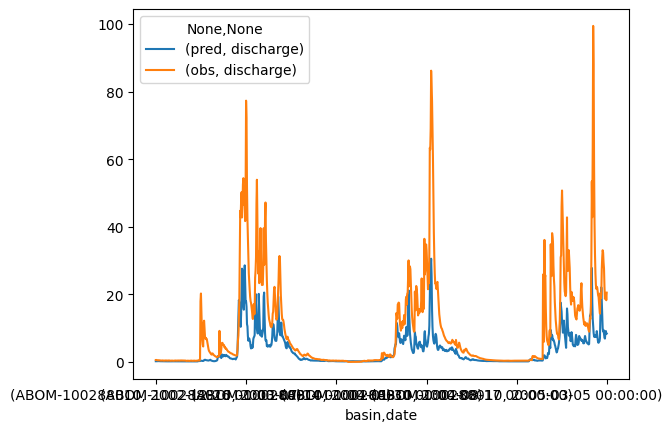

In [12]:
df.iloc[1000:2000].plot()

In [5]:
import evaluate
bulk_m = evaluate.metrics.get_all_metrics(results)
basin_m = evaluate.metrics.get_basin_metrics(results)

In [59]:
bad_gauge_path = '/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph/metadata/matching/bad_gauges.txt'
bad_gauges = pd.read_csv(bad_gauge_path, header=None)[0].to_list()
print(len(bad_gauges))

131


In [51]:
slough_gauges = sites[sites['name'].str.contains('slough', case=False)].index.to_list()
canal_gauges = sites[sites['name'].str.contains('canal', case=False)].index.to_list()

In [52]:
bad_gauges.extend(canal_gauges)
bad_gauges.extend(slough_gauges)
print(len(bad_gauges))

359


In [53]:
basin_m[basin_m.index.isin(bad_gauges)]['discharge']['NSE']

ABOM-24491010       -0.011611
ABOM-573135010   -1796221.625
EAUF-A2280030      -19.046659
EAUF-A2430030      -59.959679
ECCC-05AB019        -0.314825
ECCC-05AB042         0.213686
ECCC-05AD013        -0.213912
ECCC-05AD017        -14.47297
ECCC-05AE029        -3.325306
ECCC-05BL004         -0.24307
ECCC-05BM015     -2154.604248
UKEA-055036      -1029.194458
UKEA-2133           -0.543913
USGS-02196485       -7.643862
USGS-11504290      -71.723137
USGS-11509200       -0.644356
USGS-13068300       -0.759015
USGS-14187600    -1832.284302
USGS-14211820     -485.151123
USGS-14315900       -8.496987
Name: NSE, dtype: object

(-1.0, 1.0)

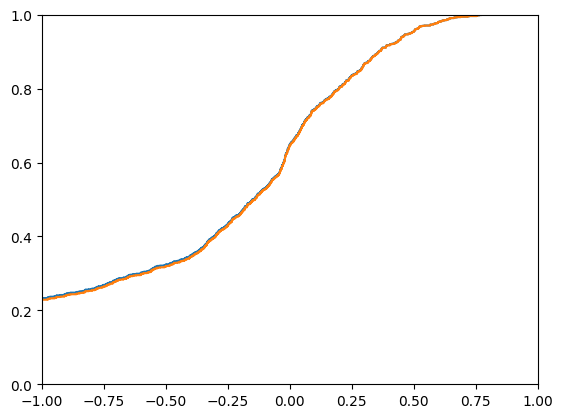

In [63]:
basin_m_filt = basin_m[~basin_m.index.isin(bad_gauges)]

plt.ecdf(basin_m['discharge']['NSE'].dropna().tolist())
plt.ecdf(basin_m_filt['discharge']['NSE'].dropna().tolist())
plt.xlim([-1,1])

In [82]:
nse = basin_m_filt['discharge']['NSE'].dropna().sort_values()
# nse = nse[nse>-1]

nse

USGS-02235500   -28442.470703
USGS-13095175   -25624.941406
ECCC-08NJ026    -13235.512695
USGS-12452550   -10412.171875
UKEA-2034        -6900.274902
                     ...     
ECCC-05CA004         0.722662
USGS-12323760        0.753945
USGS-14206241         0.75437
ECCC-08NK002         0.763939
ECCC-08NH005         0.773574
Name: NSE, Length: 1084, dtype: object

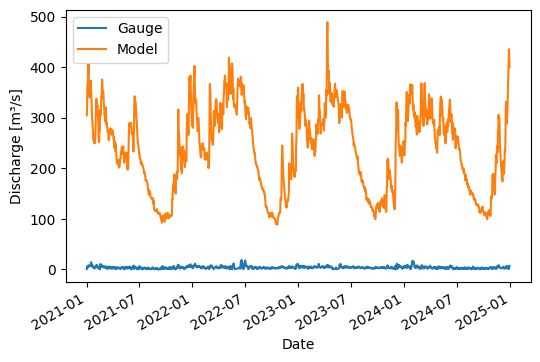

In [68]:
basin = 'USGS-14211820'

df = results.xs(basin, level='subbasin').sort_index()
df = df.droplevel(0, axis=0)
df.columns = ['_'.join(ml_col) for ml_col in df.columns]
df = df[df.index > pd.Timestamp('2020-12-31')]


fig, ax = plt.subplots(1,1, figsize=(6,4))
df['obs_discharge'].plot(ax=ax, label='Gauge')
df['pred_discharge'].plot(ax=ax, label='Model')
# if 'pred_discharge_std' in df.columns:
#     x = df.index
#     y = df['pred_discharge']
#     error = df['pred_discharge_std']
    # plt.fill_between(x, low, high, alpha=0.4, facecolor='tab:orange', antialiased=True)

plt.legend()
ax.set_ylabel('Discharge [m³/s]')
ax.set_xlabel('Date')
plt.show()
# fig.savefig(run_dir / 'figures' / f"timeseries_{basin}.png", dpi=300)

In [78]:
sites

,name,area,active,latitude,longitude,last_updated,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider_misc,geometry,provider
site_id,,,,,,,,,,,,,,,
ABOM-4405010,Tuggeranong Creek upstream Sewer Crossing,NaN,False,-35.406972,149.057806,2025-09-09,1986-02-05,2025-09-06,0.001,49.105,0.336364,13994.0,None,POINT (149.05781 -35.40697),abom
ABOM-3637010,Molonglo River at Oaks Estate,NaN,False,-35.337306,149.229083,2025-09-09,1963-06-12,2025-09-06,0.001,841.093,3.901357,22558.0,None,POINT (149.22908 -35.33731),abom
ABOM-1293010,Molonglo River at Burbong,NaN,False,-35.335611,149.313222,2025-09-09,1950-01-01,2025-09-06,0.001,373.139,1.543206,25349.0,None,POINT (149.31322 -35.33561),abom
ABOM-1389010,Paddys River at Riverlea,NaN,False,-35.382750,148.966833,2025-09-09,1957-03-30,2025-09-06,0.001,160.227,1.083808,23703.0,None,POINT (148.96683 -35.38275),abom
ABOM-1708010,Queanbeyan River at Tinderry,NaN,False,-35.614417,149.349972,2025-09-09,1966-08-03,2025-09-06,0.001,352.073,1.965813,21035.0,None,POINT (149.34997 -35.61442),abom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UKEA-351221005,Tilley Bridge,NaN,True,50.891450,0.361642,2025-09-09,1950-03-15,2025-09-07,0.005,11.600,0.254726,27428.0,{'guid': '3c4c5ec6-39cf-4b33-bef4-52c36d33db86'},POINT (0.36164 50.89145),ukea
UKEA-4047,Blyth Oldcotes,NaN,True,53.381220,-1.077358,2025-09-09,1970-09-01,2025-09-07,0.078,55.070,0.738443,20084.0,{'guid': 'fc26adc8-491a-4f56-a5a0-20d775dc0c7a'},POINT (-1.07736 53.38122),ukea
UKEA-2884,Burlington - Worfe,NaN,True,52.695461,-2.324363,2025-09-09,1999-05-26,2025-09-07,0.001,0.819,0.053705,9182.0,{'guid': 'c8d339ae-22a7-413e-90d5-ef4884026eba'},POINT (-2.32436 52.69546),ukea


USGS-02235500
-28442.470703125


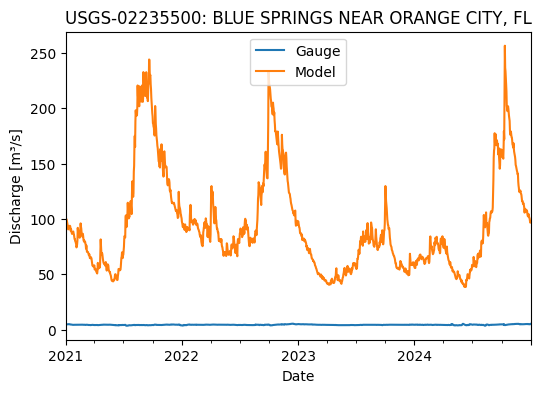

USGS-13095175
-25624.94140625


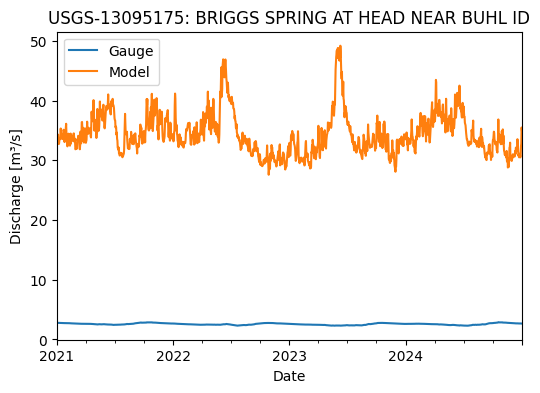

ECCC-08NJ026
-13235.5126953125


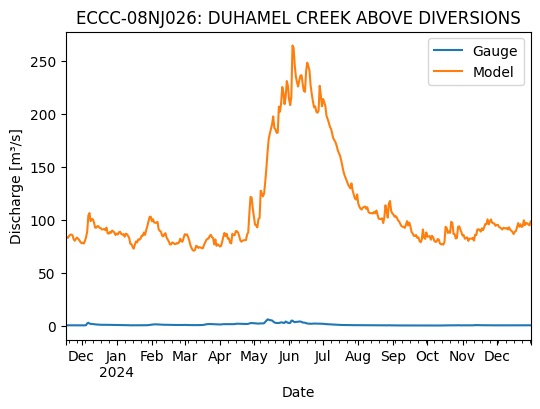

USGS-12452550
-10412.171875


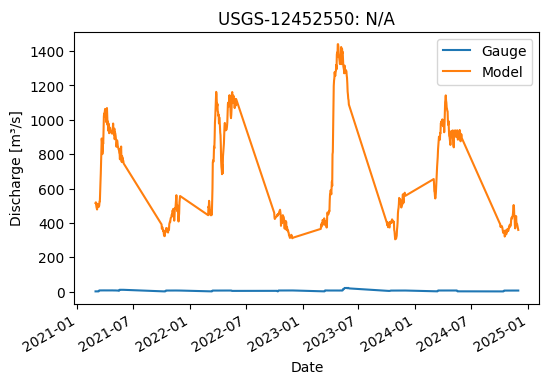

UKEA-2034
-6900.27490234375


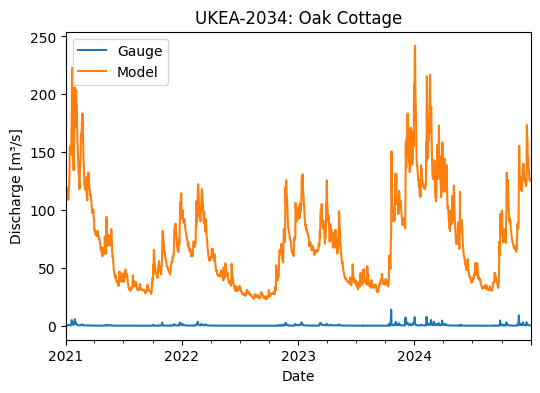

USGS-14211550
-5015.36181640625


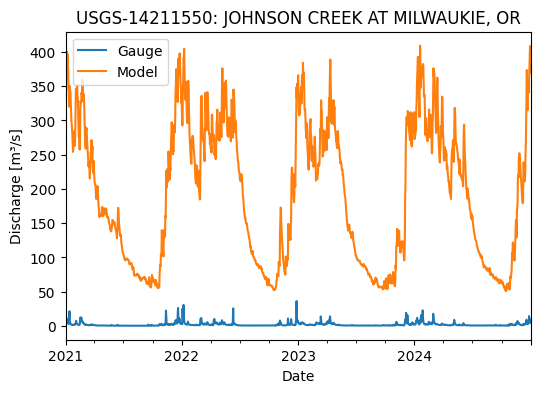

ECCC-05BM015
-2154.604248046875


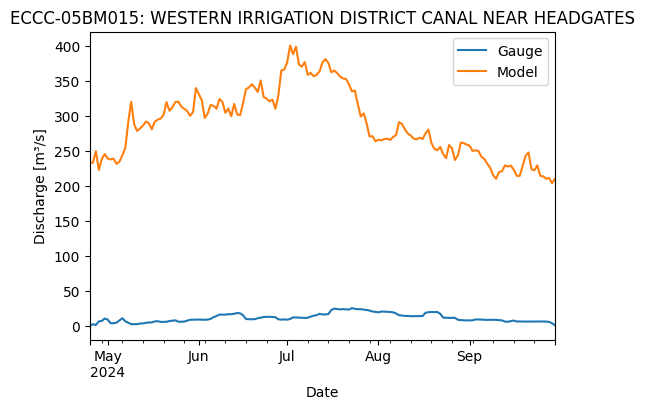

USGS-14164550
-1200.890869140625


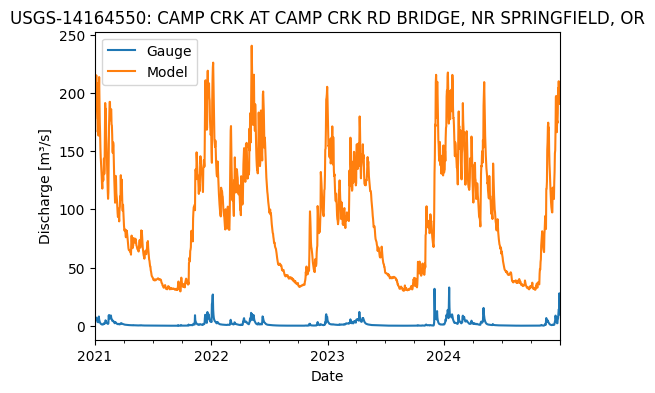

USGS-13057132
-1085.380859375


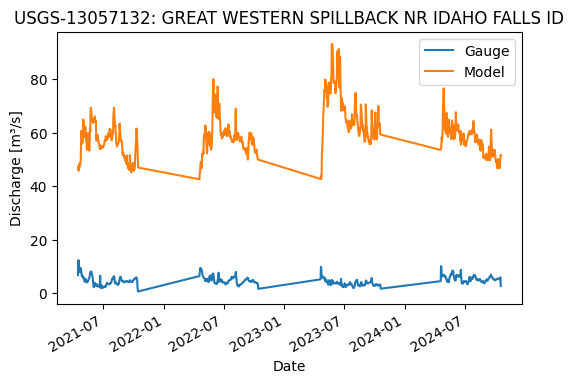

EAUF-A3800200
-992.8263549804688


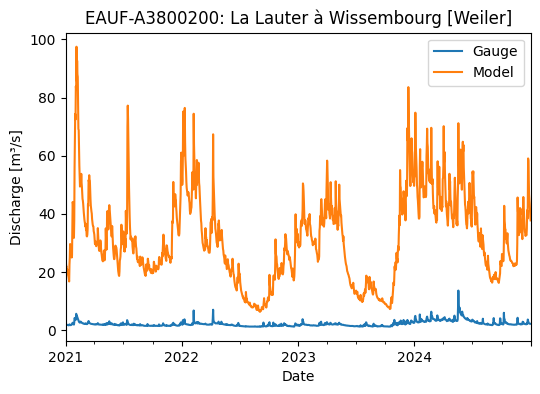

USGS-13095500
-926.7073974609375


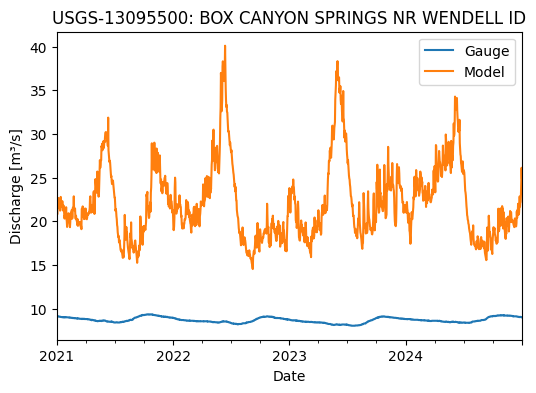

USGS-12467000
-905.8040161132812


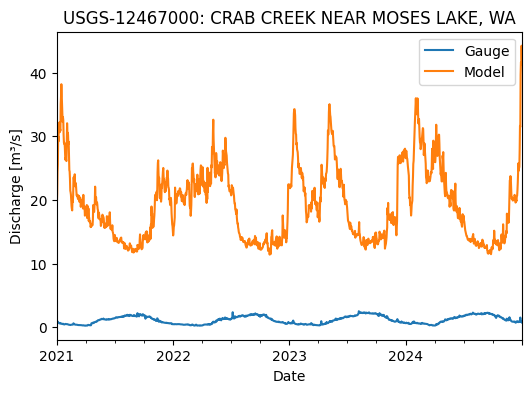

ECCC-05AC023
-582.0889282226562


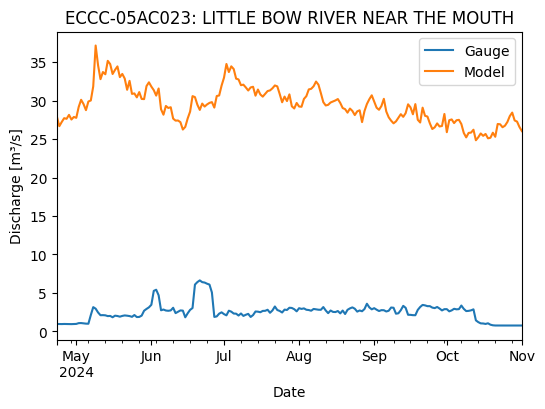

USGS-01446000
-536.9224243164062


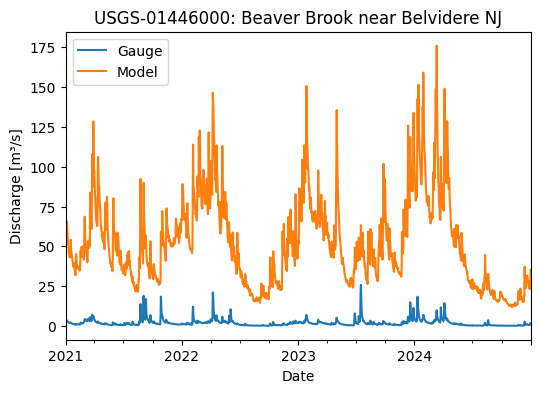

USGS-01451630
-471.1149597167969


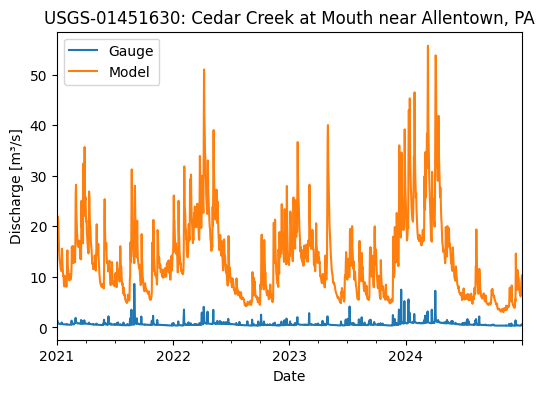

USGS-02197020
-329.640625


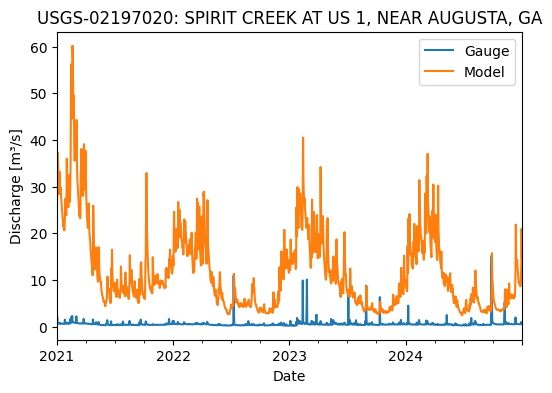

USGS-13297330
-323.7486572265625


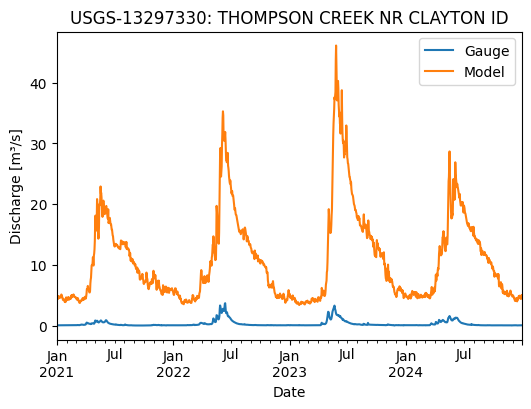

USGS-022462002
-293.9400634765625


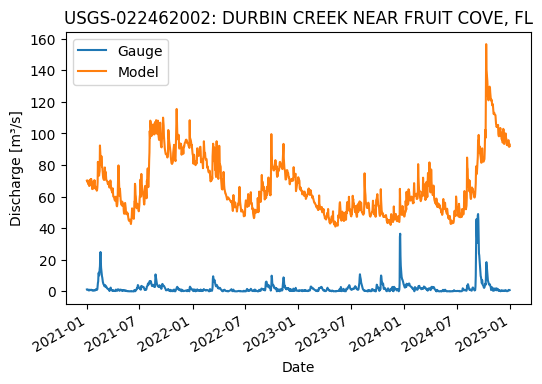

EAUF-A3120001
-258.1966247558594


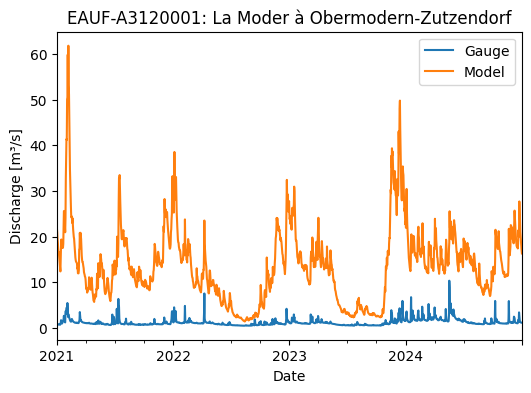

UKEA-2626
-257.625


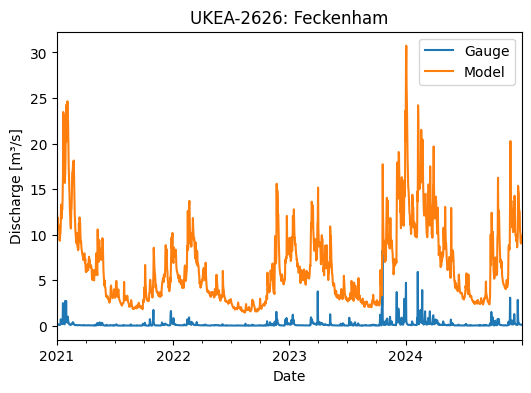

In [86]:
for basin, b_nse in nse.iloc[0:20].items():
        
    df = results.xs(basin, level='subbasin').sort_index()
    df = df.droplevel(0, axis=0)
    df.columns = ['_'.join(ml_col) for ml_col in df.columns]
    df = df[df.index > pd.Timestamp('2020-12-31')]
    
    fig, ax = plt.subplots(1,1, figsize=(6,4))
    df['obs_discharge'].plot(ax=ax, label='Gauge')
    df['pred_discharge'].plot(ax=ax, label='Model')
    
    plt.legend()
    try:
        basin_name = sites.loc[basin]['name']
    except:
        basin_name = 'N/A'
    ax.set_title(f"{basin}: {basin_name}")
    ax.set_ylabel('Discharge [m³/s]')
    ax.set_xlabel('Date')
    print(basin)
    print(b_nse)
    plt.show()

In [161]:
results['obs']['discharge'].dropna()

basin           subbasin        date      
USGS-02428400   USGS-02379500   2023-01-14     9.571094
                USGS-02380500   2023-01-14    20.501396
                USGS-02382500   2023-01-14    57.483185
                USGS-02383500   2023-01-14    92.312935
                USGS-02384500   2023-01-14    35.396057
                                                ...    
USGS-01589035   USGS-01589035   2020-07-26     2.038813
ABOM-281030010  ABOM-281030010  2023-03-24     0.094000
ABOM-224727010  ABOM-224727010  2024-03-01     0.006000
ABOM-132541010  ABOM-132541010  2024-02-02     4.341001
USGS-12048000   USGS-12048000   2021-08-20     3.737824
Name: discharge, Length: 2173546, dtype: float32

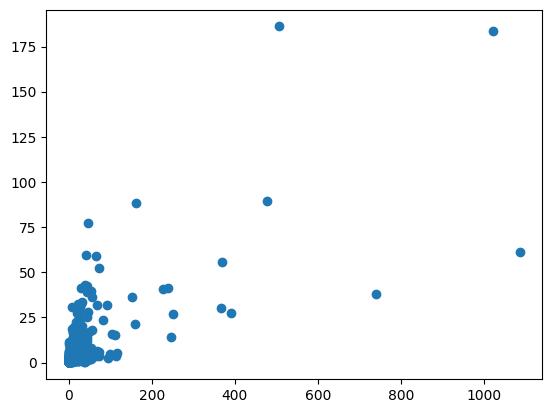

In [30]:
plt.scatter(df['obs']['discharge'], df['pred']['discharge'])

In [29]:
run_dir

PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/cached_multigraph/era5_swot_20251009_012303')

In [35]:
targets = list(bulk_m.keys())

In [ ]:
import geopandas as gpd
proj_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/distributed")
metadata_dir = proj_dir / "metadata"
basins = gpd.read_file(metadata_dir / 'matchups.geojson').set_index("HYBAS_ID")
basins.index = basins.index.astype(str)
basins

In [ ]:
import evaluate
pred = evaluate.predict(trainer.model, dataloader, denormalize=False)

In [ ]:
pred

In [ ]:
x = pred.xs('2021-02-08', level='date')


x['pred']['discharge']

In [ ]:
x['pred']['discharge'].hist()

In [ ]:
basins_pred = basins.merge(x['pred']['discharge'], left_index=True, right_index=True)
basins_pred.plot('discharge')

In [ ]:
plt.scatter(x['obs']['discharge'], x['pred']['discharge'])
# plt.plot([0,500], [0,500], 'r--')